In [112]:
from dotenv import load_dotenv

load_dotenv()

True

In [113]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model='text-embedding-3-large')

In [114]:
# 벡터DB 불러오기
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore
import os

index_name = 'tax-index'
pinecone_api_key = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=pinecone_api_key)

vectorstore = PineconeVectorStore(
    index_name=index_name,
    embedding=embedding
)

In [115]:
query = "연봉 5천만원 거주자의 소득세는 얼마인가요"

retriever = vectorstore.as_retriever(search_kwargs={'k': 2})
retriever.invoke(query)

[Document(id='66d2b4ce-de5c-4f20-9ee3-55f8b7e3a08e', metadata={'source': './data/tax.docx'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n| 종합소득 과세표준          | 세율                                         |\n\n|-------------------|--------------------------------------------|\n\n| 1,400만원 이하     | 과세표준의 6퍼센트                             |\n\n| 1,400만원 초과     5,000만원 이하     | 84만원 + (1,400만원을 초과하는 금액의 15퍼센트)  |\n\n| 5,000만원 초과   8,800만원 이하     | 624만원 + (5,000만원을 초과하는 금액의 24퍼센트) |\n\n| 8,800만원 초과 1억5천만원 이하    | 3,706만원 + (8,800만원을 초과하는 금액의 35퍼센트)|\n\n| 1억5천만원 초과 3억원 이하         | 3,706만원 + (1억5천만원을 초과하는 금액의 38퍼센트)|\n\n| 3억원 초과    5억원 이하         | 9,406만원 + (3억원을 초과하는 금액의 38퍼센트)   |\n\n| 5억원 초과      10억원 이하        | 1억 7,406만원 + (5억원을 초과하는 금액의 42퍼센트)|\n\n| 10억원 초과        | 3억 8,406만원 + (10억원을 초과하는 금액의 45퍼센트)|\n\n\n\n\n\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 

In [116]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [117]:
def retrieve(state: AgentState) -> AgentState:
    """ 사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다. """
    
    query = state['query']
    docs = retriever.invoke(query)
    
    return {'context': docs}
    

In [118]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.2')

In [119]:
from langchain import hub

generate_prompt = hub.pull("rlm/rag-prompt")

d:\workspace\langgraph_work\.venv\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [120]:
def generate(state: AgentState) -> AgentState:
    """ 주어진 state를 기반으로 RAG 체인을 사용하여 응답을 생성합니다. """
    
    context = state['context']
    query = state['query']
    
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    
    return {'answer': response}

In [121]:
from langchain_core.prompts import ChatPromptTemplate
#doc_relevence_prompt = hub.pull('langchain-ai/rag-document-relevance')
doc_relevence_prompt = ChatPromptTemplate.from_template(f"""
     당신은 검색된 문서가 사용자의 질문과 관련이 있는지 판별하는 전문가 이다.
     해당 질문(question)에 관련 문서(documents)이면 1을 리턴하고 그렇치 않으면 0을 리턴한다.
     
     question
     {{question}}
     
     documents
     {{documents}}
""")

In [122]:
from typing import Literal

def check_doc_relevence(state: AgentState) -> Literal['generate', 'rewrite']:
    """ 주어진 state를 기반으로 문서의 관련성을 판단합니다. """
    
    context = state['context']
    query = state['query']
    
    doc_relevence_chain = doc_relevence_prompt | llm
    response = doc_relevence_chain.invoke({'question': query, 'documents': context})    
    print(f'relevance: {response}')
    
    if response.content == '1':
        return 'generate'
    return 'rewrite'



In [123]:
query = '연봉 5천만원 거주자의 소득세는 얼마인가요?'
#query = '연봉 5천만원 세금 얼마인가요?'

context = retriever.invoke(query)
relevence_state = {'query': query, 'context': context}
result = check_doc_relevence(relevence_state)
result

relevance: content='1' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 2075, 'total_tokens': 2079, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1920}}, 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DIUfVGtCtunWqK5V3qOcX3ekrmwE2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ce0ed-296d-7a23-a4fc-fb4d58ca82f3-0' usage_metadata={'input_tokens': 2075, 'output_tokens': 4, 'total_tokens': 2079, 'input_token_details': {'audio': 0, 'cache_read': 1920}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


'generate'

In [124]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

dictionary = ["사람을 나타내는 표현 -> 거주자"]

rewrite_prompt = ChatPromptTemplate.from_template(f"""
     사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해 주세요.
     만약 변경할 필요가 없다고 판단 된다면, 사용자의 질문을 변경하지 않아도 됩니다.
     질문내용 중에 '*' 표시를 제거 한다.
     
     사전 : {dictionary}                                      
     
     질문 : {{question}}
""")

In [125]:
def rewrite(state: AgentState) -> AgentState:
    """ 사용자의 질문을 사전을 고려하여 질문을 변경합니다."""
    
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'question': query})
    print(f'rewrite: {response}')
    return {'query': response}

In [126]:
from langchain_core.prompts import PromptTemplate

hallucination_prompt = PromptTemplate.from_template("""
You are a teacher tasked with evaluating whether a student's answer is based on documents or not,
Given documents, which are excerpts from income tax law, and a student's answer;
If the student's answer is based on documents, respond with "not hallucinated",
If the student's answer is not based on documents, respond with "hallucinated".

documents: {documents}
student_answer: {student_answer}
""")

In [127]:
def check_hallucination(state: AgentState) -> Literal['hallucinated', 'not hallucinated']:
    answer = state['answer']
    context = state['context']
    
    hallucitation_chain = hallucination_prompt | llm | StrOutputParser()
    response = hallucitation_chain.invoke({'student_answer': answer, 'documents': context})
    
    print('거짓말 유무: ', response)
    
    return response

In [128]:
#query = '연봉 5천만원 거주자의 소득세는 얼마인가요?'
query = '연봉 5천만원 세금 얼마인가요?'

context = retriever.invoke(query)
generate_state = {'query': query, 'context': context}
answer = generate(generate_state)
print(f'answer: {answer}')

hallucination_state = {'answer': answer, 'context': context}
check_hallucination(hallucination_state)


answer: {'answer': AIMessage(content='제공된 문서에는 “연봉 5천만원”에 대한 구체적인 소득세·지방소득세·4대보험 등을 계산할 수 있는 세율표/공제 항목 정보가 없어 정확한 세금액을 알 수 없습니다. 문서에는 근로소득은 “기본세율”을 적용한다는 내용만 있습니다. 따라서 이 정보만으로는 연봉 5천만원의 세금이 얼마인지 산출할 수 없습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 2032, 'total_tokens': 2139, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1920}}, 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DIUfWMzFDnm20Mm0k93HnypEvKPDN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce0ed-2fe2-7ed3-8c77-b147f53a3fcc-0', usage_metadata={'input_tokens': 2032, 'output_tokens': 107, 'total_tokens': 2139, 'input_token_details': {'audio': 0, 'cache_read': 1920}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}
거짓말 유무:  no

'not hallucinated'

In [129]:
builder = StateGraph(AgentState)

builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_node("rewrite", rewrite)

In [130]:
from langgraph.graph import START, END

builder.add_edge(START, 'retrieve')
builder.add_conditional_edges(
    'retrieve',
    check_doc_relevence,
    {
       'generate': 'generate',
       'rewrite': 'rewrite'
    }
)
builder.add_edge('rewrite', 'retrieve')
builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
       'not hallucinated': END,
       'hallucinated': 'generate'
    }
)

In [131]:
graph = builder.compile()

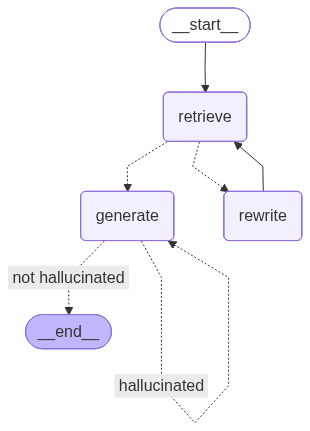

In [132]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [134]:
#query = '연봉 5천만원 거주자의 소득세는 얼마인가요?'
#연봉 5천만원 직장인의 소득세는?
initial_state = {'query': "연봉 5천만원 직장인의 소득세는 얼마인가요?"}
response = graph.invoke(initial_state)
response

relevance: content='0' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 1999, 'total_tokens': 2003, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1792}}, 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DIUgFLE106tjmLnKl7AQWVVb8xk8D', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ce0ed-dddf-77d0-a90c-00f865508a36-0' usage_metadata={'input_tokens': 1999, 'output_tokens': 4, 'total_tokens': 2003, 'input_token_details': {'audio': 0, 'cache_read': 1792}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
rewrite: 연봉 5천만원 거주자의 소득세는 얼마인가요?
relevance: content='1' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 2075, 'total_tokens': 2079, 'completi

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='66d2b4ce-de5c-4f20-9ee3-55f8b7e3a08e', metadata={'source': './data/tax.docx'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n| 종합소득 과세표준          | 세율                                         |\n\n|-------------------|--------------------------------------------|\n\n| 1,400만원 이하     | 과세표준의 6퍼센트                             |\n\n| 1,400만원 초과     5,000만원 이하     | 84만원 + (1,400만원을 초과하는 금액의 15퍼센트)  |\n\n| 5,000만원 초과   8,800만원 이하     | 624만원 + (5,000만원을 초과하는 금액의 24퍼센트) |\n\n| 8,800만원 초과 1억5천만원 이하    | 3,706만원 + (8,800만원을 초과하는 금액의 35퍼센트)|\n\n| 1억5천만원 초과 3억원 이하         | 3,706만원 + (1억5천만원을 초과하는 금액의 38퍼센트)|\n\n| 3억원 초과    5억원 이하         | 9,406만원 + (3억원을 초과하는 금액의 38퍼센트)   |\n\n| 5억원 초과      10억원 이하        | 1억 7,406만원 + (5억원을 초과하는 금액의 42퍼센트)|\n\n| 10억원 초과        | 3억 8,406만원 + (10억원을 초과하는